In [ ]:
#2.clean&prepare the data
#3. visual inspection 
#4.stationarity test(ADF & KPSS)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [59]:
stock=yf.download("RELIANCE.NS",start = "2016-03-26", end="2026-03-26")

[*********************100%***********************]  1 of 1 completed


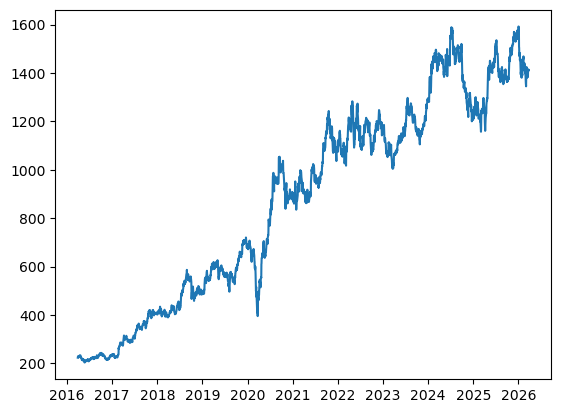

In [10]:
plt.plot(stock.Close)

In [40]:
import math

In [61]:
stock["lagged_prices"]=stock["Close"].shift(1)

In [79]:
stock["returns"]=(stock["Close"]/stock["Close"].shift(1))-1

In [83]:
stock

Price,Close,High,Low,Open,Volume,lagged_prices,returns
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,,
Date,,,,,,,
2016-03-28,223.593750,226.069850,222.552913,225.697335,18070240,NaN,NaN
2016-03-29,227.066833,228.326788,223.549898,224.338735,15871250,223.593750,0.015533
2016-03-30,229.433350,230.463230,228.480160,228.480160,14453294,227.066833,0.010422
2016-03-31,229.027969,231.394510,226.288929,228.107662,30833349,229.433350,-0.001767
2016-04-01,226.672424,229.269038,224.601707,227.691349,12381116,229.027969,-0.010285
...,...,...,...,...,...,...,...
2026-03-19,1384.800049,1415.699951,1376.099976,1388.000000,16498373,1408.099976,-0.016547
2026-03-20,1414.400024,1430.000000,1396.099976,1398.000000,22994918,1384.800049,0.021375


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from pandas_datareader.wb import download

from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.rcParams.update({
    "figure.facecolor":"#FAFAFA",
    "axes.facecolor":"#FAFAFA",
    "axes.spines.top":False,
    "axes.spines.right":False,
    "font.family":"DejaVu sans",
})
print("All libraries imported successfully")

All libraries imported successfully


In [ ]:
COUNTRY = 'IN'
INDICATOR= 'NY.GDP.MKTP.CD'
START_YEAR=1970
END_YEAR=2023

In [3]:
df=download(
    indicator=INDICATOR,
    country=COUNTRY,
    start=START_YEAR,
    end=END_YEAR
)
df.head()

NY.GDP.MKTP.CD
country year                
India   2023    3.638489e+12
        2022    3.346107e+12
        2021    3.167271e+12
        2020    2.674852e+12
        2019    2.835606e+12

In [ ]:
df=df.reset_index()
df=df.drop(columns=['country'])
df=df.rename(columns={
    'year':'Year',
    'NY.GDP.MKTP.CD':'GDP'})

In [4]:
df["Year"]=pd.to_datetime(df["Year"],format='%Y')
df=df.sort_values("Year")
print(f"download {len(df)} annual observations ({df.Year.min()}-{df.Year.max()})")
df.head()

download 54 annual observations (1970-01-01 00:00:00-2023-01-01 00:00:00)


,Year,GDP
53,1970-01-01,6.242248e+10
52,1971-01-01,6.735140e+10
51,1972-01-01,7.146470e+10
50,1973-01-01,8.551767e+10
49,1974-01-01,9.952660e+10


In [7]:
df['Log_GDP']=np.log(df['GDP'])


In [15]:
ts=df.set_index('Year')['Log_GDP']

print("Series Summary")
print(ts.describe().round(4))
print(f'\nFirst Value: {ts.iloc[0]:.4f}')
print(f'\nLast Value: {ts.iloc[-1]:.4f}')#-1 refers to the last location

Series Summary
count    54.0000
mean     26.9114
std       1.1850
min      24.8572
25%      26.0877
50%      26.7252
75%      28.0917
max      28.9226
Name: Log_GDP, dtype: float64

First Value: 24.8572

Last Value: 28.9226


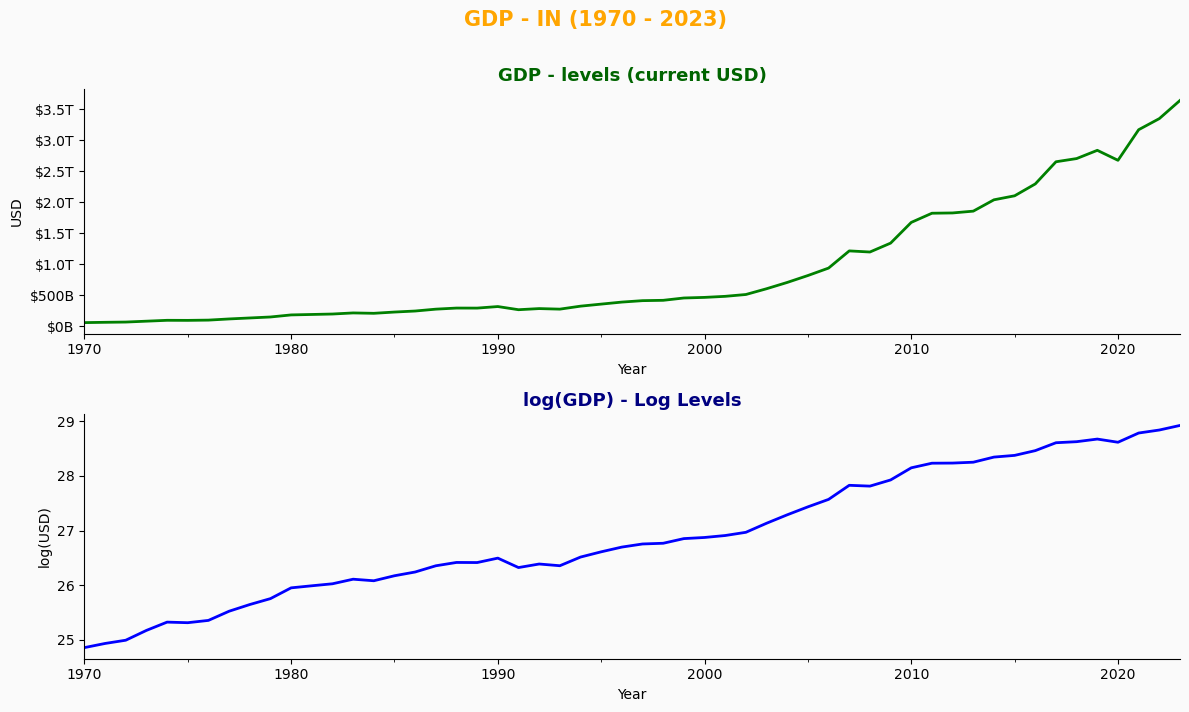


 Observations: clear upward trend - likely non-stationary in levels.


In [21]:
fig, axes=plt.subplots(2,1,figsize=(12,7))

df.plot(x='Year',y='GDP',ax=axes[0],color='Green',lw=2, legend=False)
axes[0].set_title('GDP - levels (current USD)', fontsize=13, fontweight='bold',color='DarkGreen')
axes[0].set_ylabel('USD',fontsize=10)
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x,_:f'${x/1e12:.1f}T' if x>= 1e12 else f'${x/1e9:.0f}B')
)

ts.plot(ax=axes[1],color='Blue',lw=2)
axes[1].set_title('log(GDP) - Log Levels', fontsize=13, fontweight='bold', color='Navy')
axes[1].set_ylabel('log(USD)', fontsize=10)
axes[1].set_xlabel('Year',fontsize=10)

plt.suptitle(f'GDP - {COUNTRY} ({START_YEAR} - {END_YEAR})',
             fontsize=15,fontweight='bold',y=1.01,color='Orange')
plt.tight_layout()
plt.show()

print('\n Observations: clear upward trend - likely non-stationary in levels.')

    